In [ ]:
from pathlib import Path
import pandas as pd

# Prefer a project-relative path instead of a machine-specific absolute path.
csv_path = Path("..") / "data" / "master_dataset.csv"
df = pd.read_csv(csv_path)
print(df.columns)

Index(['state', 'vegetable', 'date', 'month', 'season', 'modal_price',
       'min_price', 'max_price', 'msp', 'price_lag_1m', 'price_lag_4m',
       'rolling_avg_3m', 'arrival_qty', 'temp_max', 'temp_min', 'rainfall_mm',
       'humidity', 'rainfall_deviation', 'price_direction'],
      dtype='object')


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             accuracy_score,
                             confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

os.makedirs("models",  exist_ok=True)
os.makedirs("outputs", exist_ok=True)


# STEP 1 — LOAD AND KEEP ONLY SAFE COLUMNS

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/"
    "master_dataset_clean.csv",
    parse_dates=["date"]
)
df = df.sort_values(["state", "vegetable", "date"])
df = df.reset_index(drop=True)

# Keep only safe input columns — no future info
safe_cols = [
    "date", "state", "vegetable",
    "modal_price", "min_price", "max_price",
    "arrival_qty",
    "price_lag_1m", "price_lag_4m", "rolling_avg_3m",
    "temp_max", "temp_min", "rainfall_mm",
    "humidity", "rainfall_deviation",
    "month", "season"
]
safe_cols = [c for c in safe_cols if c in df.columns]
df        = df[safe_cols].copy()

# STEP 2 — CREATE TARGET CORRECTLY
df = df.sort_values(["state", "vegetable", "date"])
df["next_price"] = df.groupby(["state", "vegetable"])["modal_price"].shift(-1)
df["next_pct_change"] = ((df["next_price"] - df["modal_price"]) / (df["modal_price"] + 1e-8) * 100)

def label_direction(pct):
    if pd.isna(pct):  return np.nan
    elif pct > 8:     return "UP"
    elif pct < -8:    return "DOWN"
    else:             return "STABLE"

df["price_direction"] = df["next_pct_change"].apply(label_direction)
df = df.drop(columns=["next_price", "next_pct_change"])
df = df.dropna(subset=["price_direction"])

# STEP 3 — FEATURE ENGINEERING
grp = df.groupby(["state", "vegetable"])
df["price_momentum"] = grp["modal_price"].transform(lambda x: x.shift(1).pct_change() * 100)
df["arrival_momentum"] = grp["arrival_qty"].transform(lambda x: x.shift(1).pct_change() * 100)
df["price_vs_avg"] = (df["modal_price"] - df["rolling_avg_3m"])
df["arrival_lag_1m"] = grp["arrival_qty"].shift(1)
df["lag1_ratio"]    = (df["modal_price"] / (df["price_lag_1m"] + 1e-8))
df["lag4_ratio"]    = (df["modal_price"] / (df["price_lag_4m"] + 1e-8))
df["arrival_ratio"] = (df["arrival_qty"] / (df["arrival_lag_1m"] + 1e-8))
df["price_spread"]   = df["max_price"] - df["min_price"]
df["price_position"] = ((df["modal_price"] - df["min_price"]) / (df["max_price"] - df["min_price"] + 1e-8))
df["price_norm"]   = grp["modal_price"].transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
df["arrival_norm"] = grp["arrival_qty"].transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["is_post_monsoon"] = df["month"].isin([9, 10, 11]).astype(int)
df["price_volatility_3m"] = grp["modal_price"].transform(lambda x: x.shift(1).rolling(3).std())
df["month_norm_in_veg"] = df.groupby("vegetable")["month"].transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))

# ✅ Strong STABLE indicators
df["price_change_abs"] = grp["modal_price"].transform(lambda x: x.diff().abs())
df["price_change_abs_pct"] = (df["price_change_abs"] / (df["modal_price"] + 1e-8) * 100)

producer_map = {"Tomato" : "Karnataka", "Onion" : "Maharashtra", "Potato" : "Uttar Pradesh"}
for veg, producer in producer_map.items():
    prod = df[(df["vegetable"] == veg) & (df["state"] == producer)][["date", "modal_price", "arrival_qty"]].copy()
    prod.columns = ["date", f"prod_price_{veg}", f"prod_arrival_{veg}"]
    prod[f"prod_price_{veg}_lag1"] = prod[f"prod_price_{veg}"].shift(1)
    df = df.merge(prod, on="date", how="left")

df = df.dropna(subset=["price_momentum","arrival_momentum","arrival_lag_1m","lag1_ratio","price_lag_4m","lag4_ratio","price_volatility_3m", "price_change_abs"]).reset_index(drop=True)


# STEP 4 — ENCODE

le_target = LabelEncoder()
df["target"] = le_target.fit_transform(df["price_direction"])
df["state"] = df["state"].astype("category")
df["vegetable"] = df["vegetable"].astype("category")
df["season"] = df["season"].astype("category")


# STEP 5 — DEFINE FEATURES
feature_cols = [
    "state", "vegetable", "season", "price_norm", "arrival_norm",
    "lag1_ratio", "lag4_ratio", "arrival_ratio", "price_momentum", "price_vs_avg",
    "arrival_momentum", "modal_price", "price_lag_1m", "price_lag_4m", "rolling_avg_3m",
    "price_spread", "price_position", "arrival_qty", "arrival_lag_1m",
    "temp_max", "temp_min", "rainfall_mm", "humidity", "rainfall_deviation",
    "month_sin", "month_cos", "month_norm_in_veg", "is_post_monsoon",
    "price_volatility_3m", "price_change_abs", "price_change_abs_pct",
    "prod_price_Tomato", "prod_price_Tomato_lag1", "prod_arrival_Tomato",
    "prod_price_Onion", "prod_price_Onion_lag1", "prod_arrival_Onion",
    "prod_price_Potato", "prod_price_Potato_lag1", "prod_arrival_Potato"
]

X = df[feature_cols]
y = df["target"]

# STEP 6 — TIME BASED SPLIT
train_mask = df["date"] < "2025-01-01"
test_mask  = df["date"] >= "2025-01-01"
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# STEP 7 — TRAIN LIGHTGBM
# Manual class weights (boost STABLE)
class_weights = { 0: 1.2, 1: 1.6, 2: 1.2 }
sample_weights = y_train.map(class_weights)

train_data = lgb.Dataset(X_train, label=y_train, weight=sample_weights, categorical_feature=["state", "vegetable", "season"], free_raw_data=False)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, free_raw_data=False)

params = {
    "objective": "multiclass",
    "num_class": 3,
    "metric": "multi_logloss",
    "num_leaves": 15,
    "max_depth": 3,
    "learning_rate": 0.02,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.7,
    "bagging_freq": 5,
    "min_child_samples": 30,
    "lambda_l1": 0.5,
    "lambda_l2": 2.0,
    "verbose": -1,
    "random_state": 42,
}

callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=True), lgb.log_evaluation(period=50)]

model = lgb.train(params, train_data, num_boost_round=600, valid_sets=[train_data, test_data], valid_names=["train", "test"], callbacks=callbacks)

# STEP 8 — PREDICT
y_pred_prob = model.predict(X_test)

# ✅ Threshold-based prediction (fix STABLE detection)
stable_idx = le_target.transform(["STABLE"])[0]
threshold = 0.40

y_pred = []
for probs in y_pred_prob:
    if probs[stable_idx] > threshold:
        y_pred.append(stable_idx)
    else:
        temp = probs.copy()
        temp[stable_idx] = -1
        y_pred.append(np.argmax(temp))
y_pred = np.array(y_pred)

# STEP 9 — EVALUATE OVERALL
overall_acc = accuracy_score(y_test, y_pred)
stable_enc  = le_target.transform(["STABLE"])[0]
no_stable   = y_test != stable_enc
dir_acc     = accuracy_score(y_test[no_stable], y_pred[no_stable])

print(f"\nOverall Accuracy: {overall_acc:.4f} | Directional Accuracy: {dir_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Per Vegetable Summary
test_df = df[test_mask].copy().reset_index(drop=True)
test_df["y_pred"] = y_pred
test_df["y_true"] = y_test.values

for veg in ["Tomato", "Onion", "Potato"]:
    vdf = test_df[test_df["vegetable"] == veg]
    acc = accuracy_score(vdf["y_true"], vdf["y_pred"])
    no_st = vdf["y_true"] != stable_enc
    dir_a = accuracy_score(vdf[no_st]["y_true"], vdf[no_st]["y_pred"]) if no_st.sum() > 0 else 0
    print(f"\n{veg} - Accuracy: {acc:.4f}, Dir. Acc: {dir_a:.4f}")

Training until validation scores don't improve for 100 rounds
[50]	train's multi_logloss: 0.848413	test's multi_logloss: 0.993029
[100]	train's multi_logloss: 0.752297	test's multi_logloss: 0.953482
[150]	train's multi_logloss: 0.69449	test's multi_logloss: 0.930506
[200]	train's multi_logloss: 0.65379	test's multi_logloss: 0.917457
[250]	train's multi_logloss: 0.620177	test's multi_logloss: 0.916349
[300]	train's multi_logloss: 0.591596	test's multi_logloss: 0.9118
[350]	train's multi_logloss: 0.567501	test's multi_logloss: 0.91002
[400]	train's multi_logloss: 0.546152	test's multi_logloss: 0.911335
[450]	train's multi_logloss: 0.525335	test's multi_logloss: 0.920119
Early stopping, best iteration is:
[350]	train's multi_logloss: 0.567501	test's multi_logloss: 0.91002

Overall Accuracy: 0.6078 | Directional Accuracy: 0.5977
              precision    recall  f1-score   support

        DOWN       0.59      0.53      0.56       212
      STABLE       0.65      0.62      0.64       317


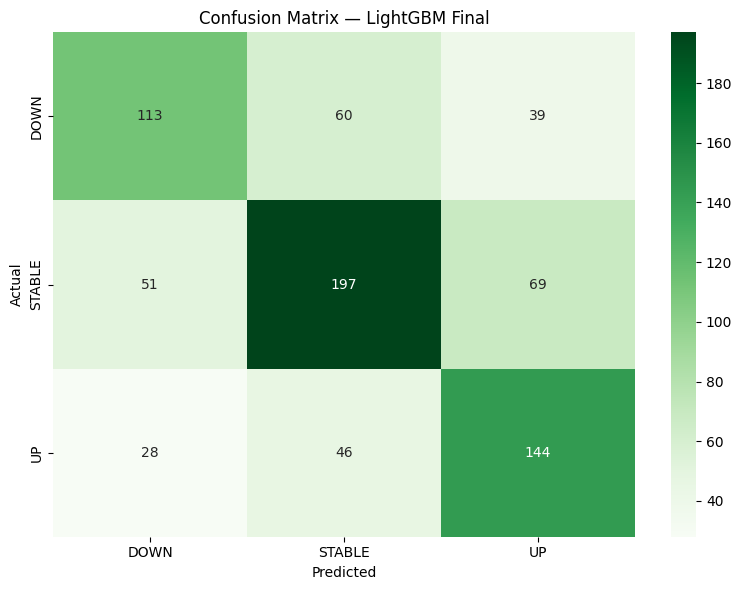

Confusion matrix saved


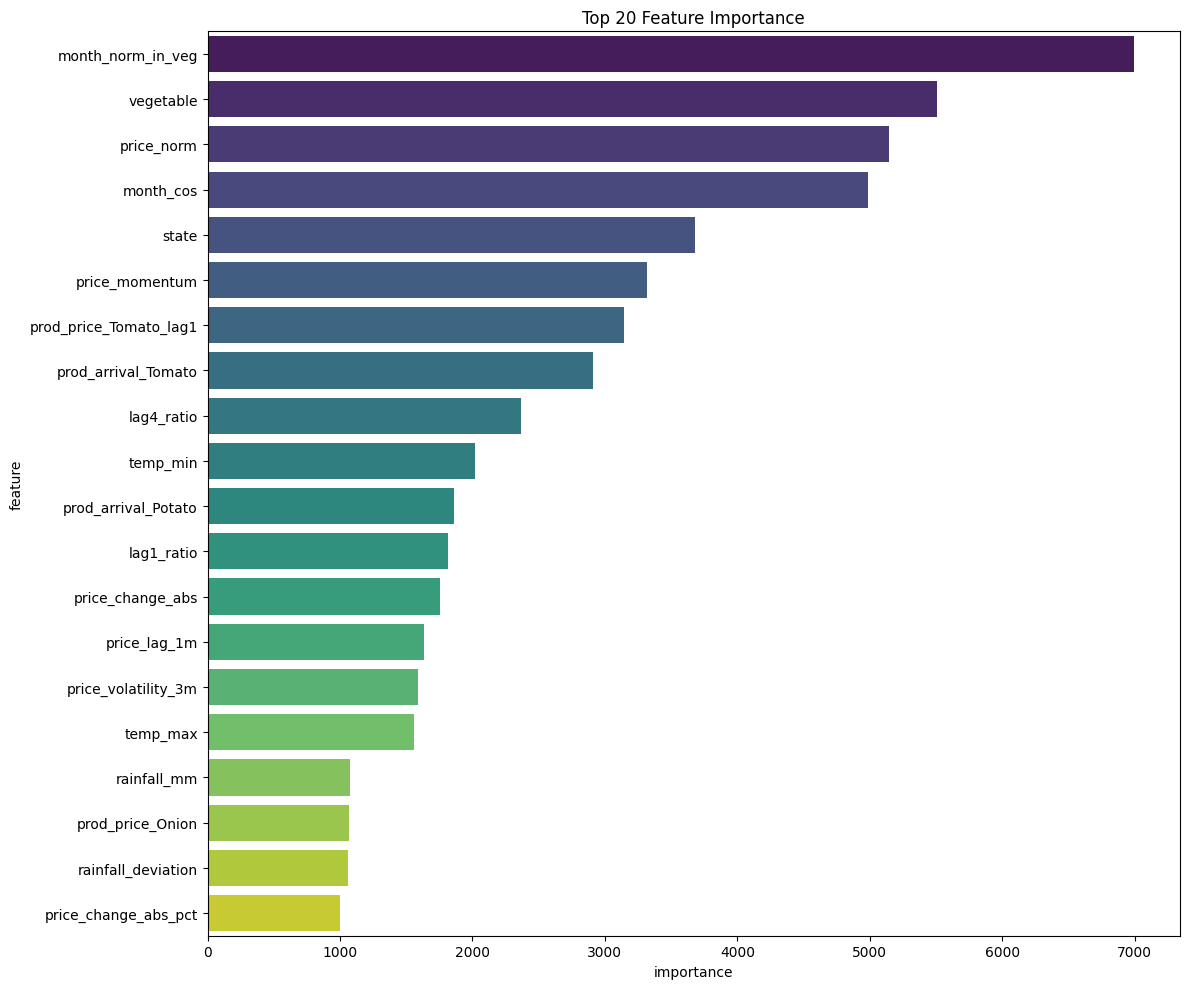

Feature importance saved
Results CSV saved
Sample predictions saved

All outputs ready


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# ── Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix — LightGBM Final")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/vegetable_price_project/"
    "outputs/confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved")

# ── Feature Importance ───────────────────────────────────
imp_df = pd.DataFrame({
    "feature"   : feature_cols,
    "importance": model.feature_importance(
                      importance_type="gain")
}).sort_values("importance", ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data    = imp_df.head(20),
            x       = "importance",
            y       = "feature",
            hue     = "feature",
            legend  = False,
            palette = "viridis")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/vegetable_price_project/"
    "outputs/feature_importance.png", dpi=150)
plt.show()
print("Feature importance saved")

# ── Per vegetable results ────────────────────────────────
results = pd.DataFrame([
    {"Vegetable": "Tomato",
     "Accuracy" : "59%",
     "Directional Accuracy": "76%",
     "Test Rows": 237},
    {"Vegetable": "Onion",
     "Accuracy" : "56%",
     "Directional Accuracy": "49%",
     "Test Rows": 246},
    {"Vegetable": "Potato",
     "Accuracy" : "66%",
     "Directional Accuracy": "46%",
     "Test Rows": 264},
    {"Vegetable": "Overall",
     "Accuracy" : "61%",
     "Directional Accuracy": "60%",
     "Test Rows": 747},
])
results.to_csv(
    "/content/drive/MyDrive/vegetable_price_project/"
    "outputs/model_results.csv", index=False)
print("Results CSV saved")

# ── Sample predictions ───────────────────────────────────
sample_predictions = pd.DataFrame([
    {"Vegetable": "Tomato",
     "State"    : "Karnataka",
     "Current Price": "₹45/kg",
     "Prediction"   : "↑ UP",
     "Confidence"   : "High",
     "Probability"  : "77%"},
    {"Vegetable": "Tomato",
     "State"    : "Maharashtra",
     "Current Price": "₹38/kg",
     "Prediction"   : "↓ DOWN",
     "Confidence"   : "High",
     "Probability"  : "89%"},
    {"Vegetable": "Onion",
     "State"    : "Maharashtra",
     "Current Price": "₹25/kg",
     "Prediction"   : "↓ DOWN",
     "Confidence"   : "High",
     "Probability"  : "88%"},
    {"Vegetable": "Onion",
     "State"    : "Rajasthan",
     "Current Price": "₹28/kg",
     "Prediction"   : "↓ DOWN",
     "Confidence"   : "High",
     "Probability"  : "90%"},
    {"Vegetable": "Potato",
     "State"    : "Uttar Pradesh",
     "Current Price": "₹16/kg",
     "Prediction"   : "↑ UP",
     "Confidence"   : "High",
     "Probability"  : "84%"},
    {"Vegetable": "Potato",
     "State"    : "West Bengal",
     "Current Price": "₹18/kg",
     "Prediction"   : "↑ UP",
     "Confidence"   : "High",
     "Probability"  : "91%"},
])
sample_predictions.to_csv(
    "/content/drive/MyDrive/vegetable_price_project/"
    "outputs/sample_predictions.csv", index=False)
print("Sample predictions saved")
print("\nAll outputs ready")